In [1]:
import numpy as np, awkward as ak, uproot, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [2]:
FILE = "/ceph/omunkombwe/digi__idea_o1_v03_60.root"
TREE = "events"

In [3]:
#pt_bins = np.array([0.65, 0.72, 0.80, 0.90, 1.00, 1.15, 1.35, 1.60, 1.90, 2.30, 2.80, 3.40, 4.10, 5.00])
#nhit_min = 54  # min shared hits to consider a track matched

In [4]:
pt_bins = np.linspace(0.5, 5.0, 50)  # uniform pt bins

In [5]:
# collectionID for DCH digis referenced by CDCHTracks
DCH_CID = np.uint32(3486206992)

In [6]:
with uproot.open(FILE) as f:
    t = f[TREE]
    arr = t.arrays([
        # MC truth
        "MCParticles.momentum.x","MCParticles.momentum.y","MCParticles.momentum.z",
        "MCParticles.PDG","MCParticles.generatorStatus",

        # CDCHTracks hit references
        "CDCHTracks.trackerHits_begin",
        "CDCHTracks.trackerHits_end",
        "_CDCHTracks_trackerHits/_CDCHTracks_trackerHits.index",
        "_CDCHTracks_trackerHits/_CDCHTracks_trackerHits.collectionID",

        # DCH-only associations (digi ↔ sim ↔ MC)
        "_DCH_DigiSimAssociationCollection_from.index",
        "_DCH_DigiSimAssociationCollection_to.index",
        "_DCHCollection_particle.index",
    ], how=dict)

In [7]:
mc_px, mc_py, mc_pz = arr["MCParticles.momentum.x"], arr["MCParticles.momentum.y"], arr["MCParticles.momentum.z"]
mc_pdg, mc_gen = arr["MCParticles.PDG"], arr["MCParticles.generatorStatus"]


In [8]:
ft_beg  = arr["CDCHTracks.trackerHits_begin"]
ft_end  = arr["CDCHTracks.trackerHits_end"]
ft_idx  = arr["_CDCHTracks_trackerHits/_CDCHTracks_trackerHits.index"]
ft_cid  = arr["_CDCHTracks_trackerHits/_CDCHTracks_trackerHits.collectionID"]

In [9]:
# ---- Links (DCH digis ↔ simhits ↔ MC)
dch_from = arr["_DCH_DigiSimAssociationCollection_from.index"]
dch_to = arr["_DCH_DigiSimAssociationCollection_to.index"]
dch_sim2mc = arr["_DCHCollection_particle.index"]


In [10]:
# ---- Truth kinematics & selections ----
mc_pt = np.sqrt(mc_px**2 + mc_py**2)
is_mu = (abs(mc_pdg) == 13)
is_final = (mc_gen == 1)
#R_prod = np.sqrt(mc_vx**2 + mc_vy**2)
#from_ip = (R_prod < 0.1)  # mm  

In [11]:
# ==========================================================
def make_digi_to_mc_map(digi_from, digi_to_sim, sim_to_mc):
    
    out = []
    for frm, to, sim2mc in zip(digi_from, digi_to_sim, sim_to_mc):
        acc = defaultdict(lambda: defaultdict(int))  # acc[d][mc] -> count (Value of the count: how many times this digi matched that MC through sim hits.)
        for d, s in zip(ak.to_numpy(frm), ak.to_numpy(to)): # for each digi 'd', get the simhit index 's'
            if d is None or s is None or s < 0 or s >= len(sim2mc):
                continue
            mcid = sim2mc[s] # get the MC index for that specific simhit
            if mcid is None or mcid < 0:
                continue
            acc[int(d)][int(mcid)] += 1 # increment count for this digi-MC pair
        # choose max-count MC per digi
        mapping = {}
        for d, bucket in acc.items():
            # deterministic tie-break: highest count, then largest mcid
            best_mcid, best_cnt = None, -1 
            for mcid, cnt in bucket.items(): 
                if (cnt > best_cnt) or (cnt == best_cnt and (best_mcid is None or mcid > best_mcid)): 
                    best_mcid, best_cnt = mcid, cnt 
            mapping[int(d)] = best_mcid # assign best MC index to this digi
        out.append(mapping) 
    return out # list of digi-to-MC maps, one per event
# ==========================================================

In [12]:
dch_digi_to_mc = make_digi_to_mc_map(dch_from, dch_to, dch_sim2mc)

In [13]:
# helper no longer required; mapping handled inline

In [14]:
# SIM-HIT totals per MC across DCH (for hit-eff denominator)
# ==========================================================
def truth_simhits_all(evt, sim_to_mc):
    c = Counter()
    for mcid in ak.to_numpy(sim_to_mc[evt]):
        if mcid is not None and mcid >= 0:
            c[int(mcid)] += 1
    return c


In [15]:
# ---Binning tallies--
den = np.zeros(len(pt_bins)-1) 
num = np.zeros(len(pt_bins)-1)

In [16]:
# ---------------- Main events loop -----------------
n_events = len(mc_pt)
for evt in range(n_events):

    mask_truth = ak.to_numpy(is_mu[evt] & is_final[evt])
    if not mask_truth.any():
        continue

    # SIM-HIT totals per MC (hit-eff denominator) and reconstructable set
    truth_hits_by_mc = truth_simhits_all(evt, dch_sim2mc)

    truth_ids_evt = np.flatnonzero(mask_truth)
    pts_evt = ak.to_numpy(mc_pt[evt])[mask_truth]

    recon_ids, recon_pts = [], []
    for tid, pt in zip(truth_ids_evt, pts_evt):
        if truth_hits_by_mc.get(int(tid), 0):
            recon_ids.append(int(tid))
            recon_pts.append(float(pt))
    if not recon_ids:
        continue

    # For each track, build contribution counts via majority digi→MC mapping
    beg_evt, end_evt = ft_beg[evt], ft_end[evt]
    idx_flat, col_flat = ft_idx[evt], ft_cid[evt]

    candidates = []  # (truth_id, shared, purity, hit_eff)
    for b, e in zip(beg_evt, end_evt):
        if b is None or e is None or e <= b:
            continue
        ids = idx_flat[b:e]
        cols = col_flat[b:e]

        total_track_hits = 0
        contrib = Counter()

        for idx_val, col_val in zip(ids, cols):
            if idx_val is None or col_val is None:
                continue
            if np.uint32(col_val) != DCH_CID:
                continue
            total_track_hits += 1
            mcid = dch_digi_to_mc[evt].get(int(idx_val))
            if mcid is not None:
                contrib[int(mcid)] += 1

        if total_track_hits == 0 or not contrib:
            continue

        best_mcid, shared = contrib.most_common(1)[0]
        purity = shared / float(total_track_hits)

        truth_total = float(truth_hits_by_mc.get(best_mcid, 0))
        hit_eff = (shared / truth_total) if truth_total > 0 else 0.0

        if purity >= 0.50 and hit_eff >= 0.50 and shared:
            candidates.append((int(best_mcid), shared, purity, hit_eff))

    # one-to-one truth↔track: keep the candidate with largest 'shared'
    best_by_truth = {}
    for mcid, shared, pur, hef in candidates:
        if (mcid not in best_by_truth) or (shared > best_by_truth[mcid][0]):
            best_by_truth[mcid] = (shared, pur, hef)

    matched_truth_ids = set(best_by_truth.keys())

    # fill num/den by pT bins for reconstructable truths
    bins_idx = np.digitize(recon_pts, pt_bins) - 1
    for tid, b in zip(recon_ids, bins_idx):
        if 0 <= b < len(den):
            den[b] += 1
            if tid in matched_truth_ids:
                num[b] += 1
# ---------------- End of events loop -----------------

In [17]:
# Wald interval (~68%)
eff, err_wald = [], []
Z = 1
for k, n in zip(num, den):
    if n == 0:
        eff.append(np.nan); err_wald.append(np.nan); continue
    p_hat = k / n
    sigma = math.sqrt(max(p_hat*(1.0 - p_hat)/n, 0.0))
    eff.append(p_hat)
    err_wald.append(Z * sigma)

In [18]:
# ---------------- Plots
centers = 0.5*(pt_bins[:-1] + pt_bins[1:])
#xerr = np.diff(pt_bins)/2

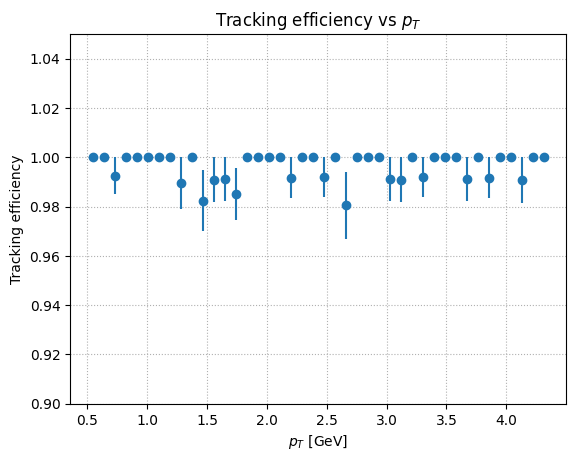

num (matched): [116.0, 122.0, 132.0, 116.0, 130.0, 122.0, 109.0, 128.0, 94.0, 116.0, 111.0, 110.0, 111.0, 132.0, 118.0, 117.0, 95.0, 115.0, 119.0, 119.0, 117.0, 123.0, 120.0, 101.0, 101.0, 126.0, 127.0, 112.0, 110.0, 111.0, 123.0, 116.0, 125.0, 140.0, 112.0, 121.0, 119.0, 104.0, 125.0, 107.0, 135.0, 92.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
den (reconstructable): [116.0, 122.0, 133.0, 116.0, 130.0, 122.0, 109.0, 128.0, 95.0, 116.0, 113.0, 111.0, 112.0, 134.0, 118.0, 117.0, 95.0, 115.0, 120.0, 119.0, 117.0, 124.0, 120.0, 103.0, 101.0, 126.0, 127.0, 113.0, 111.0, 111.0, 124.0, 116.0, 125.0, 140.0, 113.0, 121.0, 120.0, 104.0, 125.0, 108.0, 135.0, 92.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [19]:
plt.figure()
plt.errorbar(centers, eff, yerr=err_wald, fmt='o', linestyle='None')
plt.ylim(0.9, 1.05)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Tracking efficiency")
plt.grid(True, ls=":")
plt.title(r"Tracking efficiency vs $p_T$")
plt.savefig("eff_vs_pt_wald1.png", dpi=300)
plt.show()

#print("Bins (GeV):", list(zip(pt_bins[:-1], pt_bins[1:])))
print("num (matched):", num.tolist())
print("den (reconstructable):", den.tolist())